# Georeferencing with `georef_paulr`

Second georeferencing option alongside `processing.project`: uses a per-pixel View-Direction-Cosine calibration and per-channel boresight offset angle (each of the 5 channels points in a slightly different direction) instead of one shared analytic FOV model, with iterative height-plane intersection.

In [1]:
import xarray as xr
from velox_tools.georef_paulr import georef_series, available_channels

print(available_channels('HALO-AC3'))

['Channel1', 'Channel2', 'Channel3', 'Channel5', 'Channel6']


In [2]:
nav = xr.open_dataset('../data/HALO_nav.nc').sortby('time')

# cheap trick: boolean-mask by date first (works on unsorted data)
# instead of sorting the whole 5M-row file if you only need one day
day_mask = nav['time'].dt.strftime('%Y-%m-%d') == '2022-03-20'
nav_day = nav.where(day_mask, drop=True).sortby('time').load()
segment = nav_day.sel(time=slice('2022-03-20T10:51:00', '2022-03-20T10:51:05'))
segment.sizes

ERROR 1: PROJ: proj_create_from_database: Open of /projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/share/proj failed


Frozen({'time': 60})

In [3]:
result = georef_series(segment, channel=3)
result

<xarray.Dataset> Size: 472MB
Dimensions:  (time: 60, x-pixel: 640, y-pixel: 512)
Coordinates:
  * x-pixel  (x-pixel) int64 5kB 0 1 2 3 4 5 6 7 ... 633 634 635 636 637 638 639
  * y-pixel  (y-pixel) int64 4kB 0 1 2 3 4 5 6 7 ... 505 506 507 508 509 510 511
  * time     (time) datetime64[ns] 480B 2022-03-20T10:51:00 ... 2022-03-20T10...
Data variables:
    lat      (time, x-pixel, y-pixel) float64 157MB 78.65 78.65 ... 78.58 78.58
    lon      (time, x-pixel, y-pixel) float64 157MB -14.59 -14.59 ... -14.31
    height   (time, x-pixel, y-pixel) float64 157MB 0.0007451 ... 0.0005955
Attributes:
    description:  Georeferenced VELOX pixels (mounttree/PaulR method)
    ref_height:   0.0
    channel:      3
    campaign:     HALO-AC3

`georef_series` loads the calibration and coordinate geometry once and reuses it across the whole series -- looping `georef_frame` yourself instead re-does that (disk-bound) setup every call.

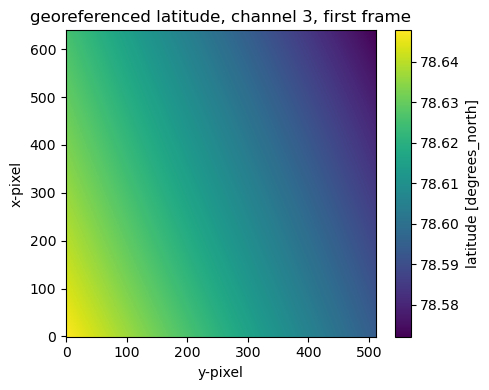

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
result.isel(time=0)['lat'].plot(ax=ax)
ax.set_title('georeferenced latitude, channel 3, first frame')
plt.tight_layout()